In [1]:
from datasets import load_dataset
import collections
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
from tqdm import tqdm
import os
import sys
sys.path.append("..")
from config import DATA_DIR, RESULTS_DIR

In [2]:
dataset = load_dataset("google/speech_commands", "v0.01")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 51093
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 6799
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 3081
    })
})


In [3]:
print(dataset.keys())
print(dataset["validation"].features)
print(dataset["validation"][0])
print(f"Label names: {dataset['train'].features['label'].names}")

dict_keys(['train', 'validation', 'test'])
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}
{'file': 'bed/2ce7534c_nohash_1.wav', 'audio': {'path': 'bed/2ce7534c_nohash_1.wav', 'array': array([ 0.00079346,  0.00247192,  0.00186157, ...,  0.00579834,
       -0.00418091,  0.00326538], shape=(16000,)), 'sampling_rate': 16000}, 'label': 20, 'is_unknown': True, 'speaker_id': '2ce7534c', 'utterance_id': 1}
Label names: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three'

In [4]:
label_names = dataset["train"].features["label"].names

DIGIT_LABELS = ['zero','one','two','three','four','five','six','seven','eight','nine']
digit_to_idx = {label_names.index(d): i for i, d in enumerate(DIGIT_LABELS)}
idx_to_digit = {i: d for i, d in enumerate(DIGIT_LABELS)}

print("Label mapping:")
for original_id, new_id in digit_to_idx.items():
    print(f"  original label {original_id} ({label_names[original_id]}) -> model label {new_id}")

Label mapping:
  original label 10 (zero) -> model label 0
  original label 11 (one) -> model label 1
  original label 12 (two) -> model label 2
  original label 13 (three) -> model label 3
  original label 14 (four) -> model label 4
  original label 15 (five) -> model label 5
  original label 16 (six) -> model label 6
  original label 17 (seven) -> model label 7
  original label 18 (eight) -> model label 8
  original label 19 (nine) -> model label 9


In [5]:

digit_ids = set(digit_to_idx.keys())

def is_digit(example):
    return example["label"] in digit_ids

dataset_digits = dataset.filter(is_digit)
print(dataset_digits)


DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 18620
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 2494
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 160
    })
})


Checking class inbalances after filtering

In [6]:
print("digit_ids:", digit_ids)

test_label_counts = collections.Counter(dataset_digits["train"]["label"])
print("\nAll labels in test set:")
for label_id, count in sorted(test_label_counts.items()):
    print(f"  {label_id} ({label_names[label_id]}): {count}")

digit_ids: {10, 11, 12, 13, 14, 15, 16, 17, 18, 19}

All labels in test set:
  10 (zero): 1866
  11 (one): 1892
  12 (two): 1873
  13 (three): 1841
  14 (four): 1839
  15 (five): 1844
  16 (six): 1863
  17 (seven): 1875
  18 (eight): 1852
  19 (nine): 1875


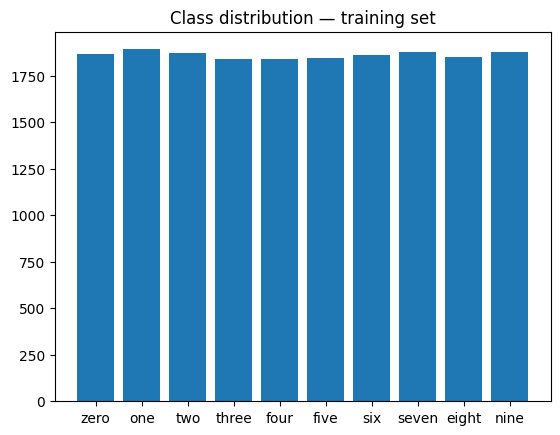

In [28]:
counts = collections.Counter(dataset_digits["train"]["label"])
plt.bar([label_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)])
plt.title("Class distribution — training set")
plt.savefig("class_balance.png")

{'file': 'eight/8f4c551f_nohash_3.wav', 'audio': {'path': 'eight/8f4c551f_nohash_3.wav', 'array': array([ 0.00015259,  0.00030518,  0.00030518, ..., -0.00027466,
       -0.00027466, -0.00036621], shape=(16000,)), 'sampling_rate': 16000}, 'label': 18, 'is_unknown': True, 'speaker_id': '8f4c551f', 'utterance_id': 3}
Audio shape: (16000,), Label: eight (eight)


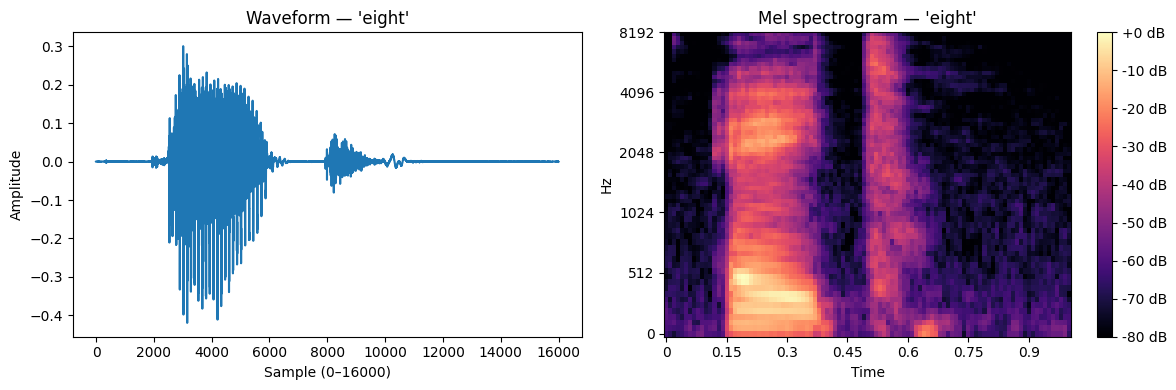

In [7]:
def compute_mel(audio_array, sr=16000, for_model=False):
    # Pad or truncate if needed
    target_length = 16000
    if len(audio_array) < target_length:
        audio_array = np.pad(audio_array, (0, target_length - len(audio_array)))
    else:
        audio_array = audio_array[:target_length]

    # Core computation — same either way
    mel = librosa.feature.melspectrogram(
        y=audio_array, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if for_model:
        # Normalize and add channel dimension for CNN
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return mel_norm[..., np.newaxis]  # (64, 101, 1)
    else:
        # Return raw dB values for visualization
        return mel_db  # (64, 101)

sample = dataset_digits["train"][0]
print(sample)
audio = np.array(sample["audio"]["array"], dtype=np.float32)
label = dataset_digits["train"].features["label"].names[sample["label"]]
word = label_names[sample["label"]]
print(f"Audio shape: {audio.shape}, Label: {label} ({word})")
mel = compute_mel(audio)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — raw waveform
axes[0].plot(audio)
axes[0].set_title(f"Waveform — '{word}'")
axes[0].set_xlabel("Sample (0–16000)")
axes[0].set_ylabel("Amplitude")

# Right — mel spectrogram

img = librosa.display.specshow(
    mel, sr=16000, hop_length=160,
    x_axis='time', y_axis='mel',
    ax=axes[1]
)
axes[1].set_title(f"Mel spectrogram — '{word}'")
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig("waveform_vs_spectrogram.png")
plt.show()

Preprocessing functions for both mel spectrograms and MFCC for comparison

audio_to_mel and compute_mel are almost the same, in compute_mel we need to extract audio data and takes in a raw numpy array, this can be used for model training if sat to true, but the purpose is for visualization. Its more flexible.
audio_to_mel takes a HuggingFace dictionary directly and does the job for us, this always produces model-ready output

In [8]:
def audio_to_mel(example):
    audio = np.array(example["audio"]["array"], dtype=np.float32)
    sr = example["audio"]["sampling_rate"]
    
    # Pad or truncate to exactly 1 second
    target_length = 16000
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    
    # Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    
    # Convert to decibels
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Normalize to [0, 1]
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    
    # Add channel dimension (64, 101) → (64, 101, 1)
    return mel_norm[..., np.newaxis]


def audio_to_mfcc(example):
    audio = np.array(example["audio"]["array"], dtype=np.float32)
    sr = example["audio"]["sampling_rate"]
    
    # Pad or truncate to exactly 1 second
    target_length = 16000
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    
    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=40, n_fft=400, hop_length=160
    )
    
    # Normalize each coefficient independently
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
    
    # Add channel dimension (40, 101) → (40, 101, 1)
    return mfcc[..., np.newaxis]

Remapping to include only the used labels (10 numbers) for matching 10 outputs that the model will have

In [9]:
def preprocess_for_training(example, use_mfcc=False):
    # Get spectrogram
    if use_mfcc:
        features = audio_to_mfcc(example)
    else:
        features = audio_to_mel(example)
    
    # Remap label from original (10-19) to model range (0-9)
    model_label = digit_to_idx[example["label"]]
    
    return features, model_label

Word: 'eight'
Mel shape:  (64, 101, 1)
MFCC shape: (40, 101, 1)
Label: 8 = 'eight'
Mel value range:  min=0.000  max=1.000
MFCC value range: min=-3.904  max=3.853


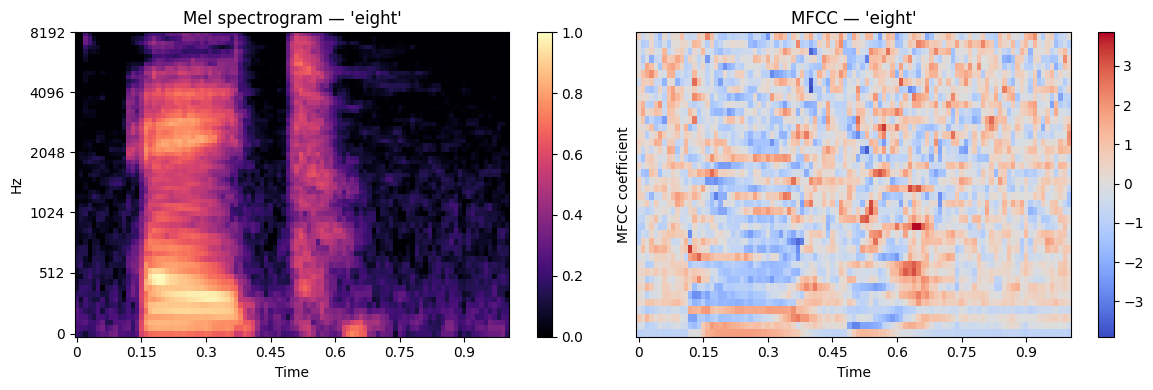

In [10]:
sample = dataset_digits["train"][0]
word = label_names[sample["label"]]

# Test wrapper — confirms remapping works
mel_features, label = preprocess_for_training(sample, use_mfcc=False)
mfcc_features, _ = preprocess_for_training(sample, use_mfcc=True)

print(f"Word: '{word}'")
print(f"Mel shape:  {mel_features.shape}")    # (64, 101, 1)
print(f"MFCC shape: {mfcc_features.shape}")   # (40, 101, 1)
print(f"Label: {label} = '{idx_to_digit[label]}'")  
print(f"Mel value range:  min={mel_features.min():.3f}  max={mel_features.max():.3f}")
print(f"MFCC value range: min={mfcc_features.min():.3f}  max={mfcc_features.max():.3f}")

# Visualize both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

img1 = librosa.display.specshow(
    mel_features[:, :, 0],
    sr=16000, hop_length=160,
    x_axis='time', y_axis='mel',
    ax=axes[0]
)
axes[0].set_title(f"Mel spectrogram — '{word}'")
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(
    mfcc_features[:, :, 0],
    sr=16000, hop_length=160,
    x_axis='time',
    ax=axes[1]
)
axes[1].set_title(f"MFCC — '{word}'")
axes[1].set_ylabel("MFCC coefficient")
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.savefig("mel_vs_mfcc.png")
plt.show()

In [11]:
print("=" * 50)
print("VERIFICATION BEFORE BUILDING DATASET")
print("=" * 50)

# 1. Check filtered dataset has only digits
print("\n1. FILTERED DATASET SIZES:")
print(f"   Train:      {len(dataset_digits['train'])} examples")
print(f"   Validation: {len(dataset_digits['validation'])} examples")
print(f"   Test:       {len(dataset_digits['test'])} examples")

# 2. Check only digit labels exist in filtered dataset
print("\n2. LABEL CHECK — should only see 10-19:")
train_labels = set(dataset_digits["train"]["label"])
print(f"   Unique labels in train: {sorted(train_labels)}")
print(f"   Expected:               {sorted(digit_ids)}")
print(f"   Match: {train_labels == digit_ids}")

# 3. Check remapping covers all labels in dataset
print("\n3. REMAPPING CHECK:")
all_labels_in_dataset = (
    set(dataset_digits["train"]["label"]) |
    set(dataset_digits["validation"]["label"]) |
    set(dataset_digits["test"]["label"])
)
unmapped = all_labels_in_dataset - set(digit_to_idx.keys())
print(f"   Labels in dataset:    {sorted(all_labels_in_dataset)}")
print(f"   Labels in digit_to_idx: {sorted(digit_to_idx.keys())}")
print(f"   Unmapped labels:      {unmapped} (should be empty set())")

# 4. Check preprocess_for_training on one sample from each split
print("\n4. PREPROCESSING CHECK — one sample per split:")
for split_name in ["train", "validation", "test"]:
    sample = dataset_digits[split_name][0]
    mel_features, label = preprocess_for_training(sample, use_mfcc=False)
    mfcc_features, label2 = preprocess_for_training(sample, use_mfcc=True)
    word = idx_to_digit[label]
    
    print(f"\n   [{split_name}]")
    print(f"   Original label: {sample['label']} ({label_names[sample['label']]})")
    print(f"   Model label:    {label} ({word})")
    print(f"   Labels match:   {label == label2}")
    print(f"   Mel shape:      {mel_features.shape} (expected (64, 101, 1))")
    print(f"   MFCC shape:     {mfcc_features.shape} (expected (40, 101, 1))")
    print(f"   Mel range:      {mel_features.min():.3f} to {mel_features.max():.3f} (expected 0.0 to 1.0)")

# 5. Check class balance in filtered training set
print("\n5. CLASS BALANCE — examples per digit:")
import collections
counts = collections.Counter(dataset_digits["train"]["label"])
for original_id in sorted(counts.keys()):
    model_id = digit_to_idx[original_id]
    word = idx_to_digit[model_id]
    bar = "█" * (counts[original_id] // 100)
    print(f"   {word:<8} (model label {model_id}): {counts[original_id]:>5} examples  {bar}")

# 6. Quick timing estimate
print("\n6. TIMING ESTIMATE:")
import time
start = time.time()
for example in list(dataset_digits["train"])[:100]:
    preprocess_for_training(example, use_mfcc=False)
elapsed = time.time() - start
per_example = elapsed / 100
total_examples = (
    len(dataset_digits["train"]) +
    len(dataset_digits["validation"]) +
    len(dataset_digits["test"])
) * 2  # x2 because mel AND mfcc
estimated_minutes = (per_example * total_examples) / 60
print(f"   100 examples took:    {elapsed:.2f} seconds")
print(f"   Per example:          {per_example*1000:.1f} ms")
print(f"   Estimated total time: {estimated_minutes:.1f} minutes")

print("\n" + "=" * 50)
print("ALL CHECKS PASSED — SAFE TO BUILD DATASET")
print("=" * 50)

VERIFICATION BEFORE BUILDING DATASET

1. FILTERED DATASET SIZES:
   Train:      18620 examples
   Validation: 2494 examples
   Test:       160 examples

2. LABEL CHECK — should only see 10-19:
   Unique labels in train: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Expected:               [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Match: True

3. REMAPPING CHECK:
   Labels in dataset:    [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Labels in digit_to_idx: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Unmapped labels:      set() (should be empty set())

4. PREPROCESSING CHECK — one sample per split:

   [train]
   Original label: 18 (eight)
   Model label:    8 (eight)
   Labels match:   True
   Mel shape:      (64, 101, 1) (expected (64, 101, 1))
   MFCC shape:     (40, 101, 1) (expected (40, 101, 1))
   Mel range:      0.000 to 1.000 (expected 0.0 to 1.0)

   [validation]
   Original label: 18 (eight)
   Model label:    8 (eight)
   Labels match:   True
   Mel shape:      (64, 101, 1) (ex

In [12]:
def build_dataset(hf_dataset, use_mfcc=False):
    X, y = [], []
    for example in tqdm(hf_dataset):
        features, label = preprocess_for_training(example, use_mfcc=use_mfcc)
        X.append(features)
        y.append(label)
    return np.array(X), np.array(y)

print("Building mel training data...")
X_train_mel, y_train = build_dataset(dataset_digits["train"], use_mfcc=False)
print(f"X_train_mel: {X_train_mel.shape}, y_train: {y_train.shape}")

print("Building mel validation data...")
X_val_mel, y_val = build_dataset(dataset_digits["validation"], use_mfcc=False)
print(f"X_val_mel: {X_val_mel.shape}, y_val: {y_val.shape}")

print("Building mel test data...")
X_test_mel, y_test = build_dataset(dataset_digits["test"], use_mfcc=False)
print(f"X_test_mel: {X_test_mel.shape}, y_test: {y_test.shape}")

print("Building mfcc training data...")
X_train_mfcc, _ = build_dataset(dataset_digits["train"], use_mfcc=True)
print(f"X_train_mfcc: {X_train_mfcc.shape}")

print("Building mfcc validation data...")
X_val_mfcc, _ = build_dataset(dataset_digits["validation"], use_mfcc=True)
print(f"X_val_mfcc: {X_val_mfcc.shape}")

print("Building mfcc test data...")
X_test_mfcc, _ = build_dataset(dataset_digits["test"], use_mfcc=True)
print(f"X_test_mfcc: {X_test_mfcc.shape}")

Building mel training data...


100%|██████████| 18620/18620 [00:13<00:00, 1385.63it/s]


X_train_mel: (18620, 64, 101, 1), y_train: (18620,)
Building mel validation data...


100%|██████████| 2494/2494 [00:01<00:00, 1714.98it/s]


X_val_mel: (2494, 64, 101, 1), y_val: (2494,)
Building mel test data...


...

X_train_mfcc: (18620, 40, 101, 1)
Building mfcc validation data...


100%|██████████| 2494/2494 [00:01<00:00, 1295.42it/s]


X_val_mfcc: (2494, 40, 101, 1)
Building mfcc test data...


100%|██████████| 160/160 [00:00<00:00, 1303.86it/s]


X_test_mfcc: (160, 40, 101, 1)


In [14]:
os.makedirs(DATA_DIR, exist_ok=True)

np.save(os.path.join(DATA_DIR, "X_train_mel.npy"), X_train_mel)
np.save(os.path.join(DATA_DIR, "X_val_mel.npy"), X_val_mel)
np.save(os.path.join(DATA_DIR, "X_test_mel.npy"), X_test_mel)
np.save(os.path.join(DATA_DIR,"X_train_mfcc.npy"), X_train_mfcc)
np.save(os.path.join(DATA_DIR, "X_val_mfcc.npy"), X_val_mfcc)
np.save(os.path.join(DATA_DIR, "X_test_mfcc.npy"), X_test_mfcc)
np.save(os.path.join(DATA_DIR, "y_train.npy"), y_train)
np.save(os.path.join(DATA_DIR, "y_val.npy"), y_val)
np.save(os.path.join(DATA_DIR, "y_test.npy"), y_test)

print("All arrays saved to disk")

All arrays saved to disk


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

        zero       0.87      1.00      0.93        13
         one       1.00      0.81      0.90        16
         two       1.00      1.00      1.00        16
       three       0.88      0.93      0.90        15
        four       1.00      0.56      0.71         9
        five       0.91      0.91      0.91        23
         six       1.00      0.64      0.78        11
       seven       0.73      1.00      0.84        16
       eight       0.94      0.94      0.94        16
        nine       0.89      0.96      0.92        25

    accuracy                           0.90       160
   macro avg       0.92      0.87      0.88       160
weighted avg       0.91      0.90      0.90       160



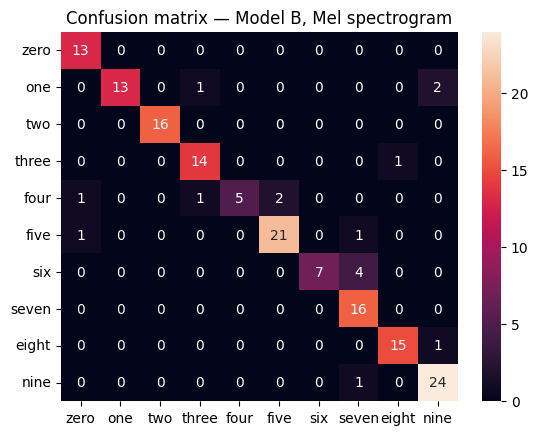

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from config import MODEL_DIR, DATA_DIR
import tensorflow as tf
import os

model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "deep_model-melSpectrogram.keras"))


# Last inn testdata
X_test_mel = np.load(os.path.join(DATA_DIR, "X_test_mel.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

# Lag TensorFlow dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test_mel, y_test)).batch(32)

y_pred = model.predict(test_ds).argmax(axis=1)
y_true = [label for _, label in test_ds.unbatch()]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=DIGIT_LABELS, yticklabels=DIGIT_LABELS)
plt.title("Confusion matrix — Model B, Mel spectrogram")
plt.savefig("confusion_matrix.png")

# Per-class metrics
print(classification_report(y_true, y_pred, target_names=DIGIT_LABELS))